In [14]:
import duckdb
import pandas as pd
import numpy as np

In [ ]:
# Check and change working directory

import os
os.chdir('..')
print(os.getcwd())

c:\Users\charl\OneDrive\Documents\Personal Projects\Ultra_Processed_Food\ultra-processed-food


In [7]:
# Check full schema

con = duckdb.connect()
schema = con.execute("DESCRIBE SELECT * FROM 'data/raw/food.parquet'").df()
print(schema.to_string())

                                column_name                                                                                                                                                                                                                                              column_type null   key default extra
0                               additives_n                                                                                                                                                                                                                                                  INTEGER  YES  None    None  None
1                            additives_tags                                                                                                                                                                                                                                                VARCHAR[]  YES  None    None  None
2                            allergens_tags   

In [9]:
df = con.execute(""" 
    SELECT code, product_name, nova_group, ingredients_text, 
                additives_n, additives_tags, categories_tags, countries_tags, 
                created_t, nutriments
    FROM 'data/raw/food.parquet'
    WHERE nova_group IS NOT NULL
""").df()

print(f"Labeled rows: {len(df):,}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Labeled rows: 1,131,979


In [15]:
def is_missing(x):
    """Check if a value is missing, whether it's None, NaN, or an empty array/list."""
    if x is None:
        return True
    if isinstance(x, (list, tuple, np.ndarray, pd.Series)):
        return len(x) == 0
    try:
        return bool(pd.isna(x))
    except (TypeError, ValueError):
        return False

def extract_text(struct_list, preferred_lang = 'en'):
    """
    Function that pulls text out of a list of {lang, text} dictionaries. Preference is English but default to the first
    language available.
    """
    if is_missing(struct_list):
        return None
    for item in struct_list:
        if item['lang'] == preferred_lang:
            return item['text']
    return struct_list[0]['text']
    

def extract_nutrient(nutrient_list, name):
    """
    Pull the per-100g value for a named nutrient outr of the nutriments list
    """
    if is_missing(nutrient_list):
        return None
    for item in nutrient_list:
        if item['name'] == name:
            return item['100g']
    return None

df['product_name_text'] = df['product_name'].apply(extract_text)
df['ingredients_text_clean'] = df['ingredients_text'].apply(extract_text)

for nutrient_name, new_col in [
    ('energy-kcal', 'energy_kcal_100g'),
    ('sugars', 'sugars_100g'),
    ('fat', 'fat_100g'),
    ('saturated-fat', 'saturated_fat_100g'),
    ('sodium', 'sodium_100g'),
]:
    df[new_col] = df['nutriments'].apply(lambda x: extract_nutrient(x, nutrient_name))

df['created_datetime'] = pd.to_datetime(df['created_t'], unit='s')

<Axes: xlabel='nova_group'>

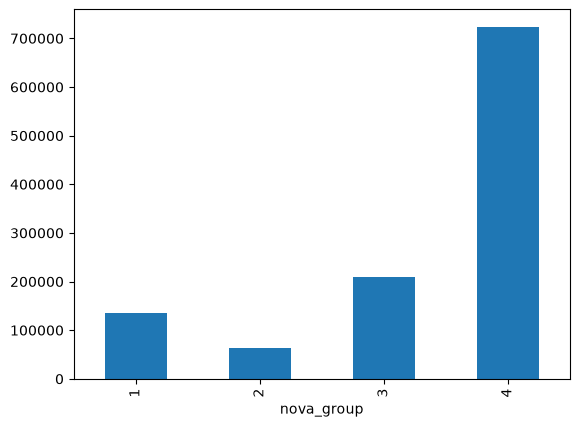

In [16]:
# Class balance

df['nova_group'].value_counts().sort_index().plot(kind='bar')